### Hyperparameter Tuning
#### Greedy search

### This Notebook is designed to be run several times with different day modes. 

In [1]:
import uuid
import numpy as np
import pandas as pd
import torch
from torch import nn
from typing import Dict, List, Any, TypedDict
from helperfunctions.helper import TrainConfig, build_dataloaders, update_cfg, rebuild_grouped_loader
from helperfunctions import intern_constants as ic
from helperfunctions import training_lib as tl
from helperfunctions.pretty_print import PrettyPrint as pp
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from enum import StrEnum

In [2]:

class DAY_MODES(StrEnum):
    LEARNING_RATE_AND_BATCH_SIZE = "lr_bs" #day1
    LEARNING_RATE_ONLY = "lr_only" #day2
    DROPOUT = "dropout" #day3
    WEIGHT_DECAY = "weight_decay" #day4
    ACTIVATION = "activation" # day5
    CONSOLIDATE = "consolidate" # day 6
    FINAL = "final" # day7

DAY_MODE_TO_IDX: Dict[DAY_MODES, int] = {
    DAY_MODES.LEARNING_RATE_AND_BATCH_SIZE : 0,
    DAY_MODES.LEARNING_RATE_ONLY : 1,
    DAY_MODES.DROPOUT : 2,
    DAY_MODES.WEIGHT_DECAY : 3,
    DAY_MODES.ACTIVATION : 4,
    DAY_MODES.CONSOLIDATE : 5,
    DAY_MODES.FINAL : 6,
}


### Setting Constants for Hyperparameter Tuning

In [3]:
###############################################################
# Select a Day mode (in same ordering like in DAY_MODE_TO_IDX)#
###############################################################
# DAY_MODE = DAY_MODES.LEARNING_RATE_AND_BATCH_SIZE
# DAY_MODE = DAY_MODES. LEARNING_RATE_ONLY
# DAY_MODE = DAY_MODES.DROPOUT
# DAY_MODE = DAY_MODES.WEIGHT_DECAY
# DAY_MODE = DAY_MODES.ACTIVATION
# DAY_MODE = DAY_MODES.CONSOLIDATE
DAY_MODE = DAY_MODES.FINAL
DAY = f"Hp_tuning_day{DAY_MODE_TO_IDX[DAY_MODE]+1}"

#Budget for Tuning
MAX_N_RUNS = 50
EPOCHS = 30 # will be increased for final day
PATIENCE = 10
MIN_DELTA = 1e-6

# Learning Rate Range
LR_FACTOR_MIN = 1/3.0
LR_FACTOR_MAX = 3.0

BATCH_SIZES = [4*14, 9*14, 18*14, 36*14]

DROPOUTS = [0.0, 0.1, 0.2, 0.25, 0.3, 0.35]
WEIGHT_DECAYS = [0.0, 1e-4, 1e-3, 1e-2, 1e-1]
ACTIVATIONS = [("relu", 0.0), ("leaky_relu", 0.01), ("leaky_relu", 0.05)]

LONG_TRAIN_EPOCHS = 150
LONG_TRAIN_PATIENCE = 150




### Experimental - Adjust Val Split

In [4]:
# avail_start = pd.Timestamp("2019-04-05 14:00:00")
# avail_end = pd.Timestamp("2021-06-30 23:50:00")
# train_end = pd.Timestamp(ic.TRAIN_END)

# times = pd.date_range(start=avail_start, 
#                       end=avail_end,
#                       freq="10min")
# n_ts_avail = len(times)

# first_year_end = train_end + pd.DateOffset(years=1)
# first_year_start = max( avail_start, train_end + pd.Timedelta(minutes=10))
# times_first_year = pd.date_range(start= first_year_start,
#                                  end=first_year_end,
#                                  freq="10min")

# n_ts_first_year = len(times_first_year)

# val_split_target = (4.0 / 12.0) * (n_ts_first_year / n_ts_avail)



### Load Config

In [5]:

# base_cfg = TrainConfig(config_name=str(DAY), val_split=val_split_target)
base_cfg = TrainConfig(config_name=str(DAY))


{
  "config_name": "Hp_tuning_day7",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-05-13 13:00:00",
  "val_end_time": "2019-10-06 22:20:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generat

In [6]:
print(f"val_start_time: {base_cfg.val_start_time}\n"
      f"val_end_time: {base_cfg.val_end_time}\n"
      f"test_start_time: {base_cfg.test_start_time}\n"
      f"test_start_end: {base_cfg.test_end_time}\n")



val_start_time: 2019-05-13 13:00:00
val_end_time: 2019-10-06 22:20:00
test_start_time: 2020-05-01 04:10:00
test_start_end: 2022-12-31 23:50:00



In [7]:
if DAY_MODE != DAY_MODES.CONSOLIDATE:
    ae_list = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=1)
    assert len(ae_list) == 1
else:
    ae_list = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=3)
    assert len(ae_list) == 3

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425



### Get the best model's config

In [8]:
if DAY_MODE != DAY_MODES.CONSOLIDATE:
    checkpdict = ae_list[0][2]
    bm_cfg =checkpdict['train_config']
    print(f"depth = {bm_cfg.depth}")

depth = 7


In [9]:
if DAY_MODE not in  [DAY_MODES.CONSOLIDATE, DAY_MODES.FINAL]:
    # through iteration cycles the cfg attributes may changed over time and are not up to date
    base_cfg = update_cfg(bm_cfg, base_cfg)
    base_cfg.layer_depths = [11]
    base_cfg.seed_list = [1845076781]
    base_cfg.epochs = EPOCHS
    base_cfg.patience = PATIENCE
    base_cfg.set_seed(base_cfg.seed_list[0])

# if DAY_MODE != DAY_MODES.FINAL:
#     base_cfg.choose_val_set = 1
# else:
#     base_cfg.choose_val_set = 2
vars(base_cfg)

{'config_name': 'Hp_tuning_day7',
 'batch_size': 252,
 'epochs': 30,
 'lr': 0.001,
 'weight_decay': 0.0,
 'grad_clip_norm': 1.0,
 'patience': 5,
 'min_delta': 1e-06,
 'depth': None,
 'input_dim': 38,
 'base_width': 38,
 'width_decay': 0.5,
 'bottleneck_min': 2,
 'activation': 'relu',
 'dropout': 0.0,
 'T0': 10,
 'Tmult': 2,
 'eta_min_lower_bound': 1e-06,
 'val_split': 0.4,
 'layer_depths': [2, 3, 4, 5],
 'min_gap': 4320,
 'ts_col': 'Date and time',
 'n_restarts': 5,
 'seed_list': [1885715325, 344118857, 1845076781, 1228853483, 909152700],
 'part1': False,
 'choose_val_set': 1,
 'signal_cols': ['Ambient temperature (converter) (°C)',
  'Drive train acceleration (mm/ss)',
  'Gear oil inlet pressure (bar)',
  'Gear oil pump pressure (bar)',
  'Gearbox speed (RPM)',
  'Generator bearing front temperature (°C)',
  'Generator bearing rear temperature (°C)',
  'Generator RPM (RPM)',
  'Hub temperature (°C)',
  'Motor current axis 1 (A)',
  'Motor current axis 2 (A)',
  'Motor current axis 3 (

### FIXED Parameters

In [10]:
# The fixed parameters depend on the tuning day
# FIXED_WEIGHT_DECAY = base_cfg.weight_decay
# FIXED_DROPOUT = base_cfg.dropout
# FIXED_ACTIVATION = getattr(base_cfg, "activation", "relu")
# FIXED_LEAKY_RELU_SLOPE = getattr(base_cfg, "leaky_relu_slope", 0.01)
# FIXED_BATCH_SIZE = base_cfg.batch_size
if DAY_MODE not in [DAY_MODES.CONSOLIDATE, DAY_MODES.FINAL]:
    BEST_LR = base_cfg.lr

In [11]:
DAY_SEED = int(ic.HP_TUNING_DAY_SEEDS[DAY_MODE_TO_IDX[DAY_MODE]])
hp_rng = np.random.default_rng(DAY_SEED)

ic.PATH_HPT.mkdir(parents=True, exist_ok=True)

day_dir = ic.PATH_HPT / DAY
day_dir.mkdir(parents=True, exist_ok=True)

prefix = f"{DAY_MODE}_"



In [12]:
train_loader, val_loader, _ = build_dataloaders(
                  train_csv_dir=ic.PATH_PC_FILTERING,
                  val_csv_dir=ic.PATH_IMPUTED,
                  test_csv_dir=ic.PATH_IMPUTED,
                  cfg=base_cfg
                  )

In [13]:
def run_one_cfg(cfg: TrainConfig, 
                prefix: str,
                train_loader: DataLoader,
                val_loader: DataLoader
                ) -> tl.EvalDict:
    
    cfg.set_seed(cfg.seed)
    
    model = tl.Autoencoder(cfg).to(cfg.device)
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr = cfg.lr,
        weight_decay=cfg.weight_decay,
    )
    
    scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None
    es = tl.EarlyStopping(min_delta=cfg.min_delta, patience=cfg.patience)
    
    run_id = uuid.uuid4().hex[:10]
    
    eval_dict, _ = tl.train_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        config=cfg,
        es=es,
        loss_fn=nn.MSELoss(reduction="none"),
        filename_prefix=f"{prefix}_Seed_{cfg.seed}_uid_{run_id}",
        scaler = scaler,
    )
    return eval_dict

In [14]:
class HP_Settings_Keys(StrEnum):
    LR = "lr"
    BATCH_SIZE = "batch_size"
    WEIGHT_DECAY = "weight_decay"
    DROPOUT = "dropout"
    ACTIVATION = "activation"
    LEAKY_RELU_SLOPE = "leaky_relu_slope"

class HP_Settings_Dict(TypedDict, total=False):
    lr : float
    batch_size : int
    weight_decay : float
    dropout : float
    activation : str
    leaky_relu_slope : float

In [15]:
minmax_factors = (1/3.0, 3.0)

def samples_around_lr(hp_rng: np.random.Generator,
                      best_lr: float,
                      min_lr: float,
                      max_lr: float
                      ) -> float:
    s = hp_rng.uniform(np.log(min_lr), np.log(max_lr))
    return float(best_lr * np.exp(s))

def build_hp_settings(num: int, mode:DAY_MODES) -> List[HP_Settings_Dict]:
    builds: List[HP_Settings_Dict] = []
    
    match mode:
        case DAY_MODES.LEARNING_RATE_AND_BATCH_SIZE:
            for _ in range(num):
                batch_size = int(hp_rng.choice(BATCH_SIZES))
                lr = samples_around_lr(hp_rng, BEST_LR, *minmax_factors)
                builds.append({
                    HP_Settings_Keys.LR: lr,
                    HP_Settings_Keys.BATCH_SIZE: batch_size,
                })
        
        case DAY_MODES.LEARNING_RATE_ONLY:
            SENTINEL_FACTORS = [1/3, 0.5, 2.0, 3.0]
            # reserve at least 4 steps or max ~20% of num for using sentinel factors as learning rates
            sent_run  = len(SENTINEL_FACTORS)
            
            if sent_run >= num:
                raise ValueError(f"num:{num} needs to be >> sent_run:{sent_run}")
            
            for i in range(sent_run):
                factor = float(SENTINEL_FACTORS[i % len(SENTINEL_FACTORS)])
                builds.append({
                    HP_Settings_Keys.LR: float(BEST_LR*factor),
                })
                
            for _ in range(num - sent_run):
                lr = samples_around_lr(hp_rng, BEST_LR, *minmax_factors)
                builds.append({
                    HP_Settings_Keys.LR: lr,
                })
        
        case DAY_MODES.DROPOUT:
            for i in range(len(DROPOUTS)):
                dropout = DROPOUTS[i]
                builds.append({
                    HP_Settings_Keys.DROPOUT: dropout,
                })
                
        case DAY_MODES.WEIGHT_DECAY:
            for i in range(len(WEIGHT_DECAYS)):
                weight_decay = WEIGHT_DECAYS[i]
                builds.append({
                    HP_Settings_Keys.WEIGHT_DECAY: weight_decay,
                })
        
        case DAY_MODES.ACTIVATION:
            for i in range(len(ACTIVATIONS)):
                activation, slope = ACTIVATIONS[i]
                builds.append({
                    HP_Settings_Keys.ACTIVATION: activation,
                    HP_Settings_Keys.LEAKY_RELU_SLOPE: slope,
                })
                
        case DAY_MODES.CONSOLIDATE:
            top = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=3)
            for (_,_,ckpt,_,_) in top:
                cfg = ckpt["train_config"]
                builds.append({
                    HP_Settings_Keys.LR: cfg.lr,
                    HP_Settings_Keys.BATCH_SIZE: cfg.batch_size,
                    HP_Settings_Keys.WEIGHT_DECAY: cfg.weight_decay,
                    HP_Settings_Keys.DROPOUT: cfg.dropout,
                    HP_Settings_Keys.ACTIVATION: cfg.activation,
                    HP_Settings_Keys.LEAKY_RELU_SLOPE: cfg.leaky_relu_slope,
                })
            
        case DAY_MODES.FINAL:
            top = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=1)
            for (_,_,ckpt,_,_) in top:
                cfg = ckpt["train_config"]
                builds.append({
                    HP_Settings_Keys.LR: cfg.lr,
                    HP_Settings_Keys.BATCH_SIZE: cfg.batch_size,
                    HP_Settings_Keys.WEIGHT_DECAY: cfg.weight_decay,
                    HP_Settings_Keys.DROPOUT: cfg.dropout,
                    HP_Settings_Keys.ACTIVATION: cfg.activation,
                    HP_Settings_Keys.LEAKY_RELU_SLOPE: cfg.leaky_relu_slope,
                })
        case _:
            raise ValueError(f"Unknown Day mode: {mode}")
        
    return builds


In [16]:
def apply_hp_settings(cfg: TrainConfig, hps: HP_Settings_Dict) -> None:
    if HP_Settings_Keys.LR in hps: cfg.lr = hps[HP_Settings_Keys.LR]
    if HP_Settings_Keys.BATCH_SIZE in hps: cfg.batch_size = hps[HP_Settings_Keys.BATCH_SIZE]
    if HP_Settings_Keys.WEIGHT_DECAY in hps: cfg.weight_decay = hps[HP_Settings_Keys.WEIGHT_DECAY]
    if HP_Settings_Keys.DROPOUT in hps: cfg.dropout = hps[HP_Settings_Keys.DROPOUT]
    if HP_Settings_Keys.ACTIVATION in hps: cfg.activation = hps[HP_Settings_Keys.ACTIVATION]
    if HP_Settings_Keys.LEAKY_RELU_SLOPE in hps: cfg.leaky_relu_slope = hps[HP_Settings_Keys.LEAKY_RELU_SLOPE]

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425

{
  "config_name": "Hp_tuning_day7",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-05-13 13:00:00",
  "val_end_time": "2019-10-06 22:20:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive tr

Day mode: final:   0%|          | 0/1 [00:00<?, ?it/s]

Epochs:   0%|          | 0/150 [00:00<?, ?ep/s]

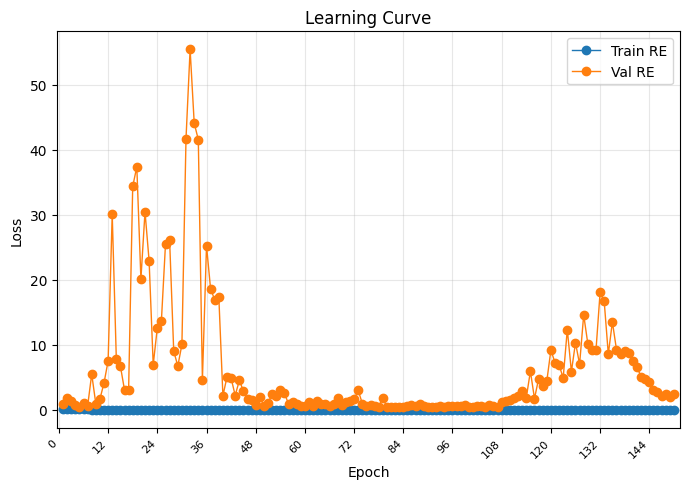

In [17]:


    
if DAY_MODE == DAY_MODES.FINAL:
    base_cfg = update_cfg(bm_cfg, base_cfg)
    base_cfg.epochs = LONG_TRAIN_EPOCHS
    base_cfg.patience = LONG_TRAIN_PATIENCE
    base_cfg.choose_val_set = 1
    base_cfg.set_seed(base_cfg.seed)
settings = build_hp_settings(num=MAX_N_RUNS, mode=DAY_MODE)

cfg_work = TrainConfig(config_name=base_cfg.config_name)
cfg_work = update_cfg(base_cfg, cfg_work)



for i in tqdm(range(len(settings)), desc=f"Day mode: {DAY_MODE}"):
    
    
    if DAY_MODE == DAY_MODES.CONSOLIDATE:
        cfg_curr = ae_list[i][2]["train_config"]
        cfg_work = update_cfg(cfg_curr, cfg_work)
        cfg_work.epochs = 80
        cfg_work.patience = 50
    
    hyperparameters = settings[i]
    
    apply_hp_settings(cfg_work, hyperparameters)
    
    results_es =run_one_cfg(cfg_work, 
                prefix, 
                train_loader=train_loader, 
                val_loader=val_loader)
    
    train_loader = rebuild_grouped_loader(train_loader,
                                                seed=cfg_work.seed, 
                                                shuffle=True, 
                                                batch_size=cfg_work.batch_size)
    val_loader = rebuild_grouped_loader(val_loader, 
                                        seed=cfg_work.seed,
                                        shuffle=False,
                                        batch_size=cfg_work.batch_size)
    
    pp.print_learning_curve(results_es["history"], save_dir=results_es["dir_path"])

In [2]:
model, (min,max) = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR,best_n=1, report_min_max=True)
print(f"Early Stopping range of all saved configurations (REs)\n"
      f"min={min}, max={max}")

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425

Early Stopping range of all saved configurations (REs)
min=0.17704901592204464, max=0.7680407693191277


In [3]:
print(torch.__version__)

2.4.1+cpu
